# Exploratory Data Analysis (EDA)

This notebook analyzes mutual fund datasets using various visualizations to identify trends, patterns, and insights.

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [12]:
import os

raw_path = "data/raw"
processed_path = "data/processed"

In [13]:
fund_master = pd.read_csv(os.path.join(processed_path,"01_fund_master.csv"))

nav = pd.read_csv(os.path.join(processed_path,"02_nav_history_cleaned.csv"))

aum = pd.read_csv(os.path.join(processed_path,"03_aum_by_fund_house.csv"))

sip = pd.read_csv(os.path.join(processed_path,"04_monthly_sip_inflows.csv"))

category = pd.read_csv(os.path.join(processed_path,"05_category_inflows.csv"))

folio = pd.read_csv(os.path.join(processed_path,"06_industry_folio_count.csv"))

performance = pd.read_csv(os.path.join(processed_path,"07_scheme_performance_cleaned.csv"))

transactions = pd.read_csv(os.path.join(processed_path,"08_investor_transactions_cleaned.csv"))

portfolio = pd.read_csv(os.path.join(processed_path,"09_portfolio_holdings.csv"))

benchmark = pd.read_csv(os.path.join(processed_path,"10_benchmark_indices.csv"))

In [14]:
print(nav.shape)

print(aum.shape)

print(transactions.shape)

(46000, 3)
(90, 5)
(32778, 13)


In [15]:
nav.info()
nav.head()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [16]:
nav["date"] = pd.to_datetime(nav["date"])
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


## 1. NAV Trend Analysis

This visualization shows the daily Net Asset Value (NAV) trend for all 40 mutual fund schemes from 2022 to 2026.

In [17]:
import plotly.express as px
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)
fig.write_image("reports/NAV_Trend.png")
fig.show()

In [18]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)
fig.write_image("reports/NAV_Trend2.png")
fig.show()

### Key Finding

Most mutual fund schemes showed an upward NAV trend during 2023, while growth slowed during the 2024 market correction.

In [19]:
nav["amfi_code"].nunique()

40

In [20]:
aum.head()
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [21]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create a new year column
aum["year"] = aum["date"].dt.year

# Check first 5 rows
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


## 2. AUM Growth Analysis

This chart compares the Assets Under Management (AUM) of different mutual fund houses from 2022 to 2025.

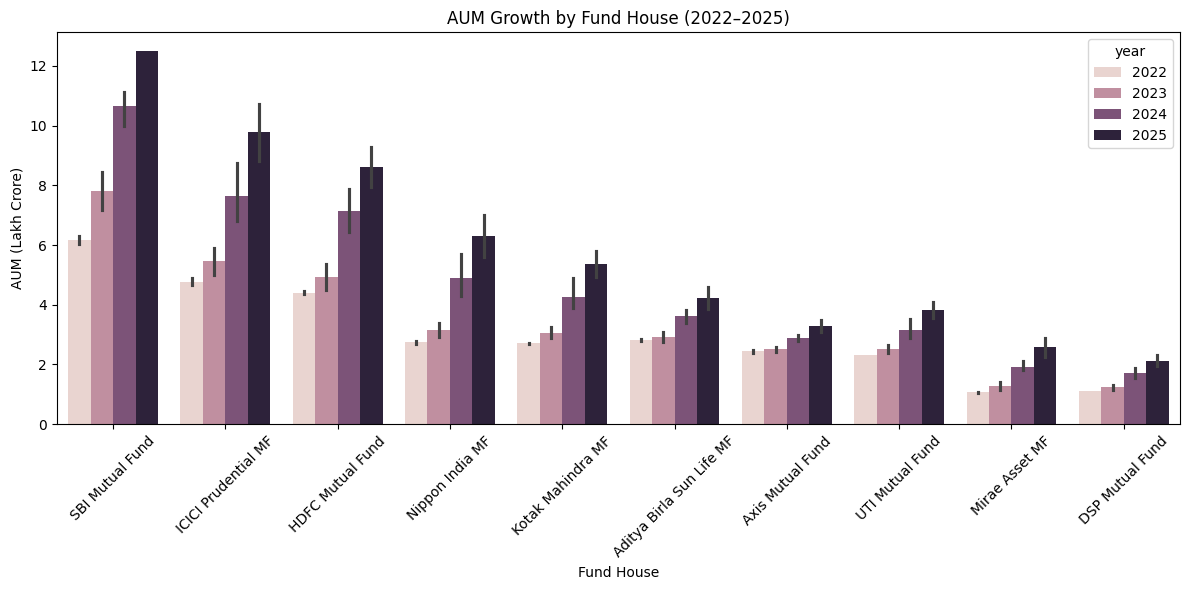

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/AUM_Growth.png")
plt.show()

### Key Finding

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses.

## 3. SIP Inflow Trend

This visualization shows the monthly SIP inflow trend from January 2022 to December 2025.

In [23]:
sip.head()
sip.info()
sip = pd.read_csv("data/processed/04_monthly_sip_inflows.csv")


<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [26]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (2022–2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (All-Time High)",
    showarrow=True,
    arrowhead=2
)
fig.write_image("reports/SIP_Inflow_Trend.png")
fig.write_image("reports/SIP_Inflow_Trend.png")
fig.show()

### Key Finding

Monthly SIP inflows increased over time and reached an all-time high of ₹31,002 crore in December 2025.

## 4. Category Inflow Heatmap

This heatmap shows the monthly net inflows across different mutual fund categories.

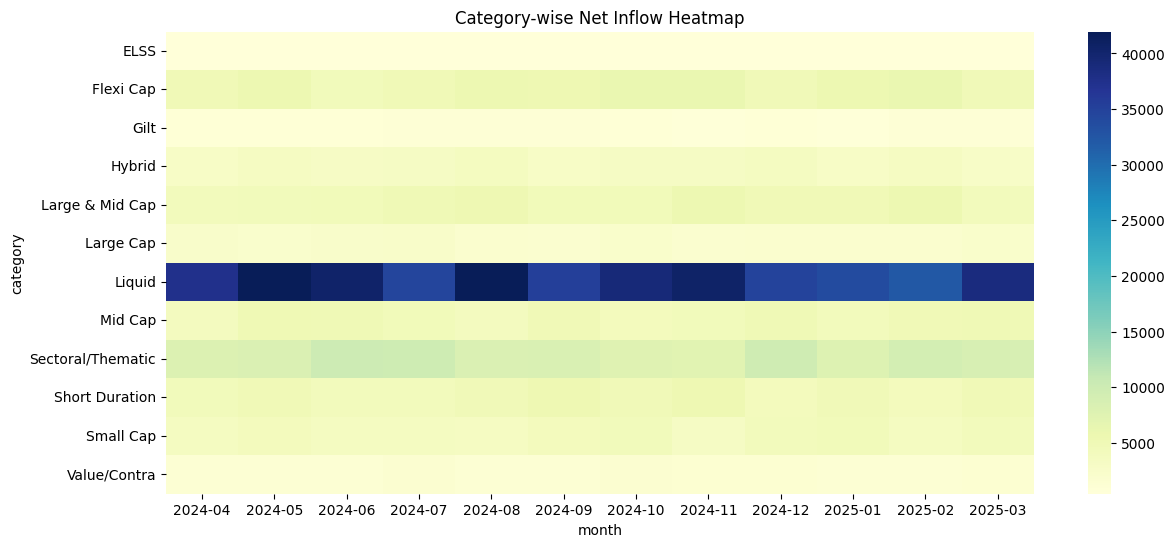

In [27]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Category-wise Net Inflow Heatmap")
plt.savefig("reports/Category_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

Some mutual fund categories consistently attracted higher inflows than others during the analysis period.

## 5. Investor Demographics

This section analyzes the distribution of investors based on age group, investment amount, and gender.

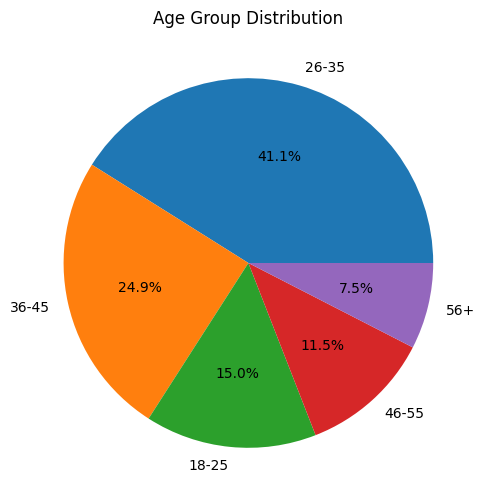

In [28]:
plt.figure(figsize=(6,6))

transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.savefig("reports/Age_Group_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

Investment patterns vary across different age groups, and the investor base includes both male and female participants.

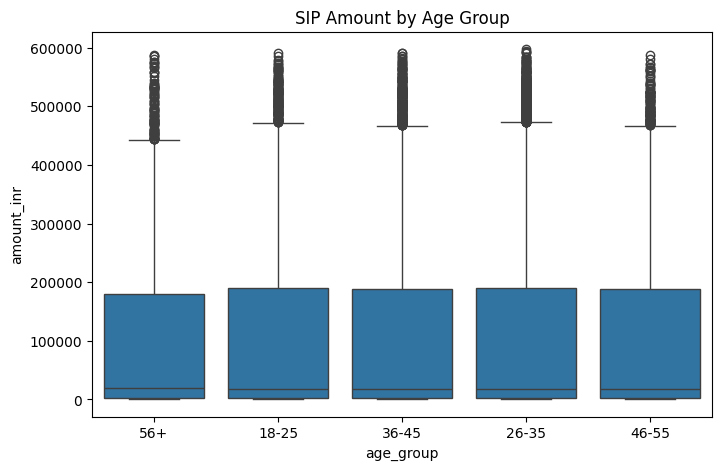

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.title("SIP Amount by Age Group")
plt.savefig("reports/SIP_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

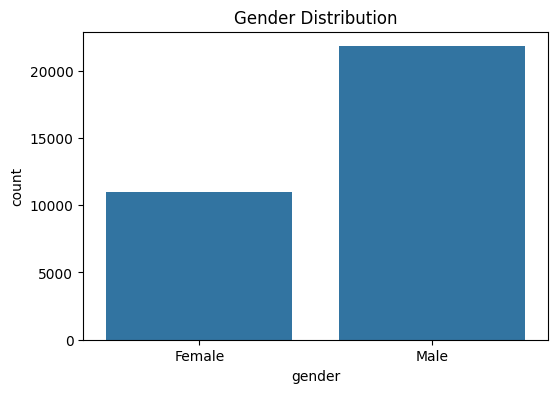

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=transactions,
    x="gender"
)
plt.title("Gender Distribution")
plt.savefig("reports/Gender_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Geographic Distribution

This section analyzes investment distribution across different states and city tiers.

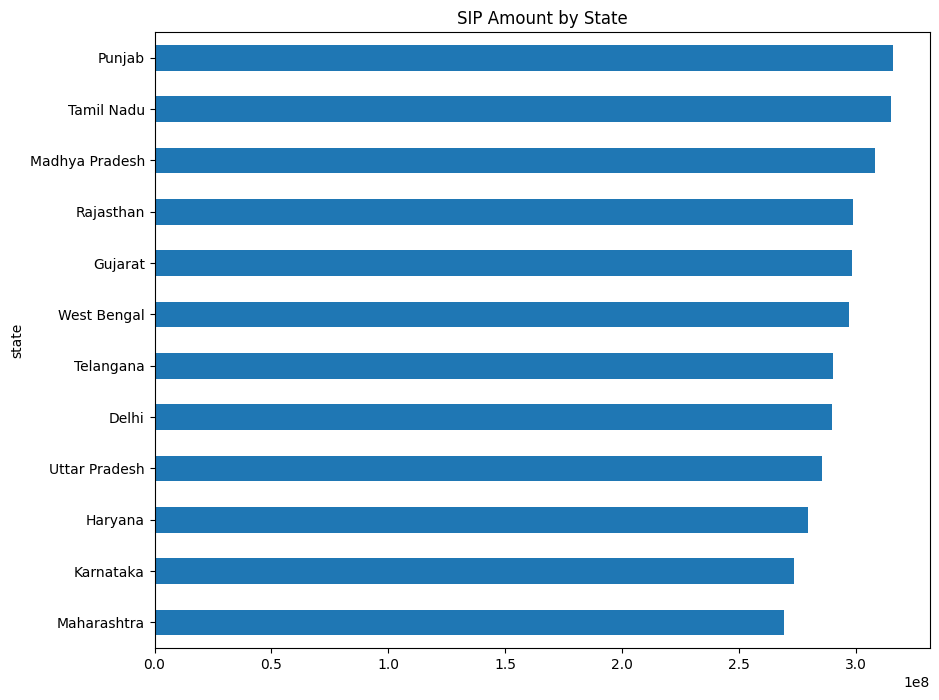

In [31]:
state_data = transactions.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))
state_data.plot(kind="barh")
plt.title("SIP Amount by State")
plt.savefig("reports/State_Wise_SIP.png", dpi=300, bbox_inches="tight")
plt.show()

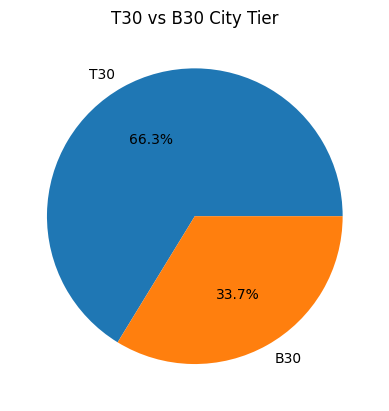

In [32]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.title("T30 vs B30 City Tier")
plt.ylabel("")
plt.savefig("reports/T30_vs_B30.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

Investment contributions differ by state, and T30 cities account for a larger share of investments than B30 cities.

## 7. Folio Count Growth

This chart shows the growth of mutual fund folios over the analysis period.

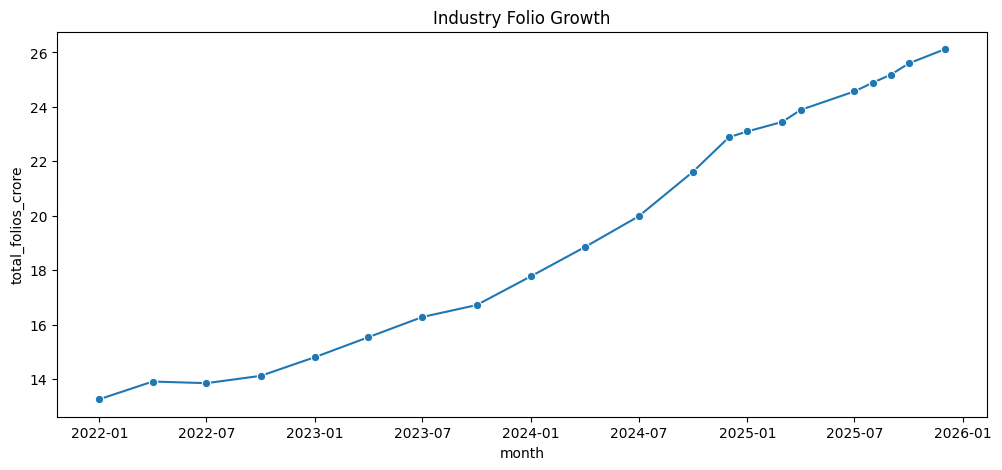

In [33]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))
sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.title("Industry Folio Growth")
plt.savefig("reports/Folio_Growth.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

The total number of mutual fund folios increased steadily from 2022 to 2025, indicating growing investor participation.

## 8. NAV Return Correlation Matrix

This heatmap shows the correlation between the NAV returns of selected mutual fund schemes.

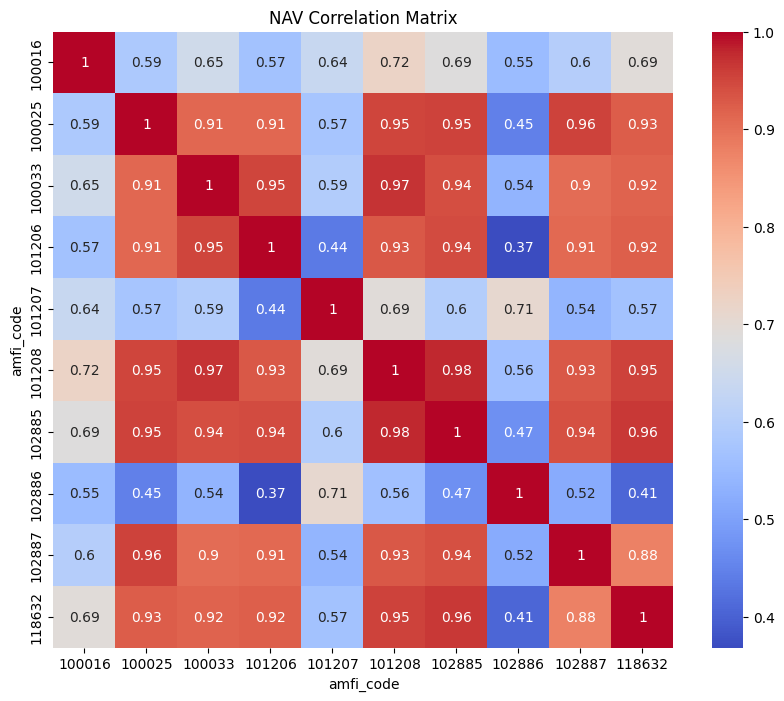

In [34]:
top10 = nav["amfi_code"].unique()[:10]

corr = (
    nav[nav["amfi_code"].isin(top10)]
    .pivot(index="date", columns="amfi_code", values="nav")
    .corr()
)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("NAV Correlation Matrix")
plt.savefig("reports/NAV_Correlation_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

Most selected mutual funds show positive correlations, indicating similar movement in NAV returns.

## 9. Sector Allocation

This chart shows the distribution of portfolio allocation across different sectors.

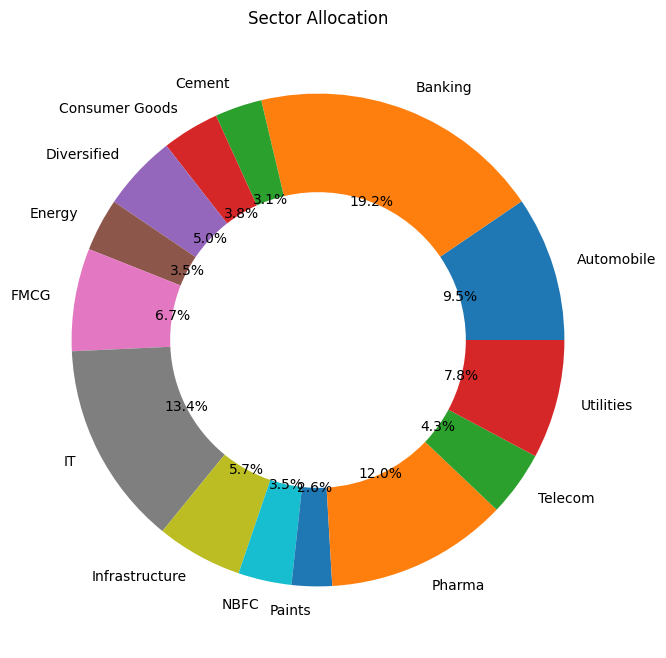

In [35]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")
plt.savefig("reports/Sector_Allocation.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

The portfolio is diversified across multiple sectors, with a few sectors contributing a larger allocation.

##  Transaction Type Distribution

This chart shows the distribution of different transaction types among investors.

C:\Users\nagen\AppData\Local\Temp\ipykernel_24060\2146802481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


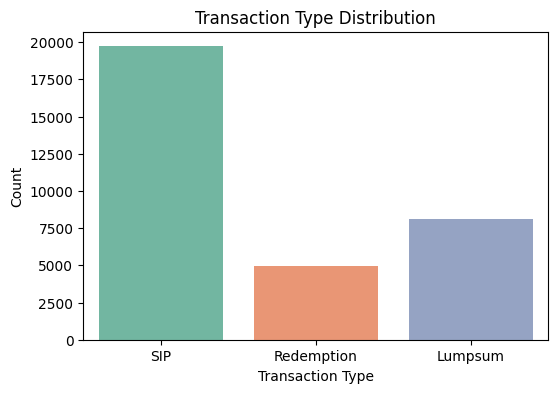

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=transactions,
    x="transaction_type",
    palette="Set2"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.savefig("reports/Transaction_Type_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

SIP transactions account for the largest share of investor transactions.

##  Expense Ratio Distribution

This histogram shows the distribution of expense ratios across mutual fund schemes.

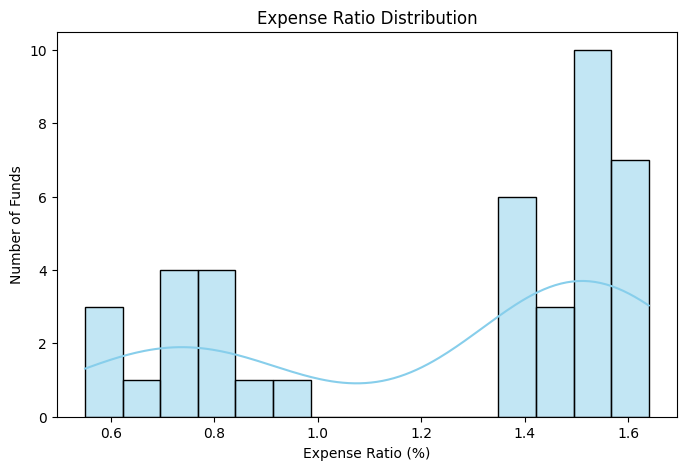

In [37]:
performance = pd.read_csv(
    os.path.join(processed_path, "07_scheme_performance_cleaned.csv")
)
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True,
    color="skyblue"
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")
plt.savefig("reports/Expense_Ratio_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

Most mutual fund schemes have expense ratios within the expected industry range.

## Top Fund Houses by Number of Schemes

This chart compares the number of mutual fund schemes offered by the leading fund houses.

C:\Users\nagen\AppData\Local\Temp\ipykernel_24060\442560998.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


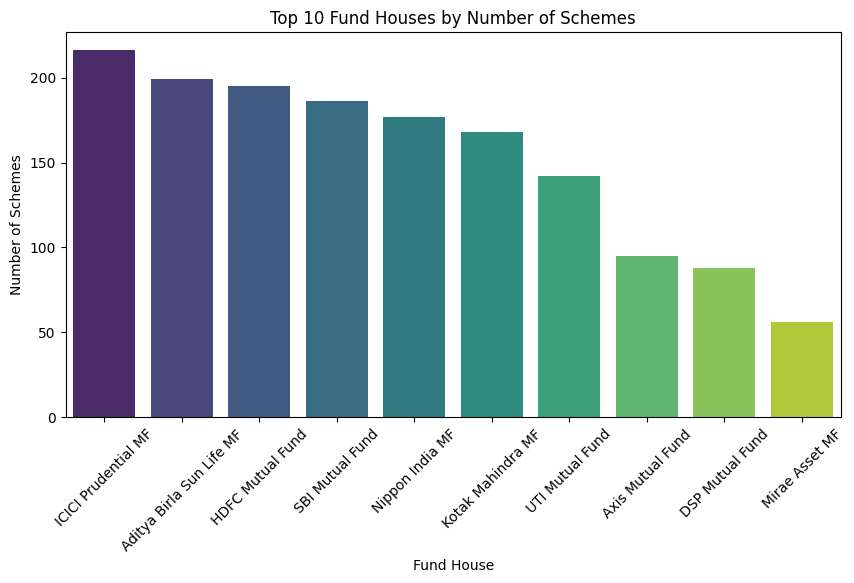

In [38]:
top_funds = (
    aum.groupby("fund_house")["num_schemes"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_funds.index,
    y=top_funds.values,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Top 10 Fund Houses by Number of Schemes")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.savefig("reports/Top_Fund_Houses.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Finding

The leading fund houses manage a larger number of mutual fund schemes than others.

# Overall EDA Summary

- Created interactive and static visualizations using Plotly, Seaborn, and Matplotlib.
- Analyzed NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, folio growth, correlation, and sector allocation.
- Identified key trends and insights from the mutual fund datasets.
- The analysis provides a comprehensive overview of mutual fund performance and investor behavior from 2022 to 2025.

In [ ]:
import os

os.makedirs("reports", exist_ok=True)